In [2]:
import torchvision
from torchvision import datasets
import torch
import matplotlib.pyplot as plt

train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform= torchvision.transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform= torchvision.transforms.ToTensor(),
    target_transform=None
)

In [3]:
from rich import print
device = 'cuda' if torch.cuda.is_available() else "cpu"


print(device)

cuda

In [9]:
class_names = train_data.classes

In [4]:
from torch.utils.data import DataLoader

BATCH_SIZE: int = 32

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size= BATCH_SIZE,
    shuffle= True,
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

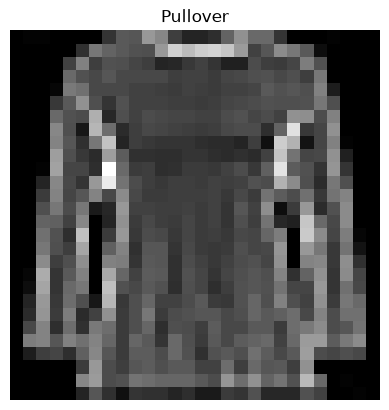

In [16]:
torch.manual_seed(42)

for train_features_batch, train_labels_batch in train_dataloader:
    random_idx = torch.randint(0, len(train_features_batch), size=(1,)).item()
    img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
    plt.imshow(img.squeeze(dim=0), cmap='gray')
    plt.axis(False)
    plt.title(class_names[label])
    break
    

In [ ]:
from torch import nn
class FashionMNISTModelV0(nn.Module):

    def __init__(self, 
                 input_shape: int,
                 hidden_layer1: int,
                 output_shape: int
                 ):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                in_features= input_shape, 
                out_features= hidden_layer1,
            ),

            # nn.ReLU(),

            nn.Linear(
                in_features= hidden_layer1,
                out_features= output_shape 
            )
        )

    def forward(self, x: torch.Tensor):
        return self.layers(x)

model_0 = FashionMNISTModelV0(
    input_shape= train_data.data.shape[1] * train_data.data.shape[2],
    hidden_layer1= 10,
    output_shape= len(train_data.classes),
).to(device)



In [48]:
model_0

FashionMNSITModelV0(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:


LEARING_RATE = 0.01
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr= LEARING_RATE
)

In [52]:
from torchmetrics import Accuracy
acc_fn = Accuracy(
    task= "multiclass",
    num_classes=len(train_data.classes)
).to(device)

In [65]:
from tqdm.auto import tqdm

torch.manual_seed(42)

epochs = 3

for epoch in tqdm(range(epochs)):

    train_loss, train_acc = 0.0, 0.0
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()

        X = X.to(device)
        y = y.to(device)

        y_logits = model_0(X)

        train_acc += acc_fn(y_logits.argmax(dim=1), y).item()

        loss = loss_fn(y_logits, y)


        optimizer.zero_grad()

        train_loss += loss.item()

        loss.backward()

        optimizer.step()

        if batch % 400 == 0:
            print(f"Batch no. {batch} , looked at {batch * len(X)}/{len(train_data)}")


    # Taking the average
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)


    test_loss, test_acc = 0.0, 0.0

    model_0.eval()

    with torch.inference_mode():

        for X_test , y_test in test_dataloader:


            X_test = X_test.to(device)
            y_test = y_test.to(device)

            test_logits = model_0(X_test)

            test_loss += loss_fn(test_logits, y_test).item()

            test_acc += acc_fn(test_logits.argmax(dim=1), y_test).item()


        test_loss /= len(test_dataloader)

        test_acc /= len(test_dataloader)


    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2%} | Test Accuracy: {test_acc:.2%}")
    print("[green]#[/green]" * 20)



  0%|          | 0/3 [00:00<?, ?it/s]

Batch no. 0 , looked at 0/60000

Batch no. 400 , looked at 12800/60000

Batch no. 800 , looked at 25600/60000

Batch no. 1200 , looked at 38400/60000

...

Batch no. 1600 , looked at 51200/60000

Train Loss: 0.4524 | Test Loss: 0.4785

Train Accuracy: 84.30% | Test Accuracy: 83.18%

####################

100%|██████████| 3/3 [01:48<00:00, 36.04s/it]


In [11]:

import torchmetrics
def eval_model(
        model: nn.Module,
        loss_fn: nn.Module,
        accuracy_fn: torchmetrics.Metric,
        data_loader: torch.utils.data.DataLoader,
        device= "cpu"
):
    loss, acc = 0.0,0.0

    model.to(device)

    model.eval()

    with torch.inference_mode():

        for X, y in tqdm(data_loader):

            X = X.to(device)
            y = y.to(device)

            y_logits = model(X)

            loss += loss_fn(y_logits, y).item()

            acc += accuracy_fn(y_logits.argmax(dim=1), y).item()

        loss /= len(data_loader)
        acc /= len(data_loader)

    print(f"Test Loss: {loss: .2f} | Test Accuracy: {acc: .2%}")

    return {
        "test_loss": loss,
        "test_accuracy": acc
    }





In [ ]:
torch.optim.Optimizer

In [33]:

def train_step(
        model: nn.Module,
        loss_fn: nn.Module,
        optimizer: torch.optim.Optimizer,
        accuracy_fn: torchmetrics.Metric,
        data_loader: torch.utils.data.DataLoader,
        device= "cpu"
):
    loss = 0.0

    model.to(device)

    model.train()

    accuracy_fn.reset()

    for X, y in tqdm(data_loader):

        X = X.to(device)
        y = y.to(device)

        y_logits = model(X)

        loss_batch = loss_fn(y_logits, y)

        optimizer.zero_grad()

        loss_batch.backward()

        loss += loss_batch.detach()

        accuracy_fn.update(
            y_logits.argmax(dim=1),
            y
        )

        # acc += accuracy_fn(y_logits.argmax(dim=1), y).item()

        optimizer.step()

    loss = loss / len(data_loader)

    acc = accuracy_fn.compute().item()

    print(f"Train Loss: {loss: .2f} | Train Accuracy: {acc: .2%}")

    return {
        "train_loss": loss,
        "train_accuracy": acc
    }


In [ ]:
def test_step(
    model: nn.Module,
    loss_fn: nn.Module,
    accuracy_fn: torchmetrics.Metric,
    data_loader: torch.utils.data.DataLoader,
    device= "cpu"
):
    loss = 0.0

    model.to(device)

    model.eval()

    accuracy_fn.reset()

    with torch.inference_mode():

        for X, y in tqdm(data_loader):

            X = X.to(device)
            y = y.to(device)

            y_logits = model(X)

            loss += loss_fn(y_logits, y).detach()

            accuracy_fn.update(y_logits.argmax(dim=1), y)

        loss = loss / len(data_loader)
        acc = accuracy_fn.compute().item()

    print(f"Test Loss: {loss: .2f} | Test Accuracy: {acc: .2%}")



In [ ]:
eval_model

In [72]:
eval_model(
    model= model_0,
    loss_fn=loss_fn,
    accuracy_fn=acc_fn,
    data_loader= test_dataloader,
    device="cuda"
)

100%|██████████| 313/313 [00:03<00:00, 93.72it/s] 


Test Loss:  0.48 | Test Accuracy:  83.18%

In [6]:
from torch import nn
from tqdm.auto import tqdm
class FashionMNISTModelV1(nn.Module):

    def __init__(self,
                 input_shape: int,
                 hidden_layer1: int,
                 output_shape: int):

        super().__init__()

        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features= input_shape,
                out_features= hidden_layer1
            ),
            nn.ReLU(),
            nn.Linear(
                in_features=hidden_layer1,
                out_features=output_shape
            ),
            nn.ReLU()
        )


    def forward(self, x: torch.Tensor):
        return self.layers(x)

In [7]:
model_1 = FashionMNISTModelV1(
    input_shape= train_data.data.shape[1] * train_data.data.shape[2],
    hidden_layer1= 10,
    output_shape= len(train_data.classes),
).to(device)

In [8]:
LEARING_RATE = 0.01
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model_1.parameters(),
    lr= LEARING_RATE
)

In [9]:
from torchmetrics import Accuracy
acc_fn = Accuracy(
    task= "multiclass",
    num_classes=len(train_data.classes)
).to(device)

In [32]:

EPOCHS = 3

for epoch in tqdm(range(EPOCHS)):
    train_step(
        model=model_1,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=acc_fn,
        data_loader=train_dataloader,
        device=device
    )

    test_step(
        model=model_1,
        loss_fn=loss_fn,
        accuracy_fn=acc_fn,
        data_loader=test_dataloader,
        device=device
    )


100%|██████████| 1875/1875 [00:23<00:00, 80.83it/s]


Train Loss:  0.86 | Train Accuracy:  66.98%

100%|██████████| 313/313 [00:03<00:00, 97.25it/s]


Test Loss:  0.90 | Test Accuracy:  65.27%

100%|██████████| 1875/1875 [00:23<00:00, 78.18it/s]


...

100%|██████████| 1875/1875 [00:23<00:00, 79.47it/s]


Train Loss:  0.85 | Train Accuracy:  67.26%

100%|██████████| 313/313 [00:03<00:00, 102.52it/s]


Test Loss:  0.89 | Test Accuracy:  65.78%

100%|██████████| 3/3 [01:20<00:00, 26.75s/it]


In [21]:
!nvidia-smi

Wed Sep 30 00:10:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 615.71.08              KMD Version: 616.92        CUDA UMD Version: 13.4     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   42C    P8              3W /   95W |     133MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----